In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import restoration, filters
import pandas as pd
import os


base_path = '/content/drive/MyDrive/assignment_1_data/'

clean_files = {
    'PD': 'clean_images/pd_icbm_normal_1mm_pn0_rf0.mnc.gz',
    'T1': 'clean_images/t1_icbm_normal_1mm_pn0_rf0.mnc.gz',
    'T2': 'clean_images/t2_icbm_normal_1mm_pn0_rf0.mnc.gz'
}

noisy_files = {
    'PD_3': 'noisy_images/pd_icbm_normal_1mm_pn3_rf0.mnc.gz',
    'PD_9': 'noisy_images/pd_icbm_normal_1mm_pn9_rf0.mnc.gz',
    'T1_3': 'noisy_images/t1_icbm_normal_1mm_pn3_rf0.mnc.gz',
    'T1_9': 'noisy_images/t1_icbm_normal_1mm_pn9_rf0.mnc.gz',
    'T2_3': 'noisy_images/t2_icbm_normal_1mm_pn3_rf0.mnc.gz',
    'T2_9': 'noisy_images/t2_icbm_normal_1mm_pn9_rf0.mnc.gz'
}



Mounted at /content/drive


In [10]:
clean_images = {}
noisy_images = {}

print("Loading clean images...")
for modality, file_path in clean_files.items():
    full_path = base_path + file_path
    if os.path.exists(full_path):
        clean_images[modality] = nib.load(full_path).get_fdata()
        print(f" {modality} clean image loaded - Shape: {clean_images[modality].shape}")
    else:
        print(f"File not found: {full_path}")

print("\nLoading noisy images...")
for key, file_path in noisy_files.items():
    full_path = base_path + file_path
    if os.path.exists(full_path):
        noisy_images[key] = nib.load(full_path).get_fdata()
        print(f"{key} noisy image loaded - Shape: {noisy_images[key].shape}")
    else:
        print(f"File not found: {full_path}")

print("All images loaded successfully!")

Loading clean images...
 PD clean image loaded - Shape: (181, 217, 181)
 T1 clean image loaded - Shape: (181, 217, 181)
 T2 clean image loaded - Shape: (181, 217, 181)

Loading noisy images...
PD_3 noisy image loaded - Shape: (181, 217, 181)
PD_9 noisy image loaded - Shape: (181, 217, 181)
T1_3 noisy image loaded - Shape: (181, 217, 181)
T1_9 noisy image loaded - Shape: (181, 217, 181)
T2_3 noisy image loaded - Shape: (181, 217, 181)
T2_9 noisy image loaded - Shape: (181, 217, 181)
All images loaded successfully!


In [11]:


def pipeline_median_anisotropic_gaussian(image):

    denoised = ndimage.median_filter(image, size=3)
    denoised = restoration.denoise_tv_bregman(denoised, weight=0.1)
    denoised = filters.gaussian(denoised, sigma=0.5, preserve_range=True)

    return denoised

def denoise_volume_fast(volume, pipeline_func):
    denoised_volume = np.zeros_like(volume)

    for slice_idx in range(volume.shape[2]):
        if slice_idx % 50 == 0:
            print(f"Processing slice {slice_idx}/{volume.shape[2]}")
        denoised_volume[:, :, slice_idx] = pipeline_func(volume[:, :, slice_idx])

    return denoised_volume



In [12]:


denoised_results = {}

for key in noisy_files.keys():
    print(f"Processing {key}...")
    denoised_results[key] = denoise_volume_fast(noisy_images[key], pipeline_median_anisotropic_gaussian)
    print(f"{key} denoised")
print("done")

Processing PD_3...
Processing slice 0/181
Processing slice 50/181
Processing slice 100/181
Processing slice 150/181
PD_3 denoised
Processing PD_9...
Processing slice 0/181
Processing slice 50/181
Processing slice 100/181
Processing slice 150/181
PD_9 denoised
Processing T1_3...
Processing slice 0/181
Processing slice 50/181
Processing slice 100/181
Processing slice 150/181
T1_3 denoised
Processing T1_9...
Processing slice 0/181
Processing slice 50/181
Processing slice 100/181
Processing slice 150/181
T1_9 denoised
Processing T2_3...
Processing slice 0/181
Processing slice 50/181
Processing slice 100/181
Processing slice 150/181
T2_3 denoised
Processing T2_9...
Processing slice 0/181
Processing slice 50/181
Processing slice 100/181
Processing slice 150/181
T2_9 denoised
done


In [13]:

#CV Calculation
def calculate_final_cv(image, modality):

    # intensity ranges for each modality
    if modality == 'T1':
        low, high = 50, 800  # Stable brain tissue range for T1
    elif modality == 'T2':
        low, high = 1000, 3000  # Established high range for T2
    else:  # PD
        low, high = 1000, 5000  # Wide range for PD with correct noise behavior

    #mask for the tissue range
    mask = (image >= low) & (image <= high)
    tissue_pixels = image[mask]

    if len(tissue_pixels) > 1000:
        mean_val = np.mean(tissue_pixels)
        std_val = np.std(tissue_pixels)
        cv = std_val / mean_val if mean_val != 0 else 0
        return cv
    return 0

print("CV calculation done")

CV calculation done


In [14]:

assignment_results = []

for modality in ['T1', 'T2', 'PD']:
    # Calculate CV for clean image
    cv_clean = calculate_final_cv(clean_images[modality], modality)

    for noise_level in ['3', '9']:
        key = f"{modality}_{noise_level}"

        # Calculate CV for noisy image
        cv_noisy = calculate_final_cv(noisy_images[key], modality)

        # Calculate CV for denoised image
        cv_denoised = calculate_final_cv(denoised_results[key], modality)

        # Calculate improvement percentage
        improvement = ((cv_noisy - cv_denoised) / cv_noisy * 100) if cv_noisy != 0 else 0

        # Store results
        assignment_results.append({
            'Modality': modality,
            'Noise Level': f'{noise_level}%',
            'Clean CV': f"{cv_clean:.4f}",
            'Noisy CV': f"{cv_noisy:.4f}",
            'Denoised CV': f"{cv_denoised:.4f}",
            'Improvement (%)': f"{improvement:.1f}%"
        })

# Create final results table
final_assignment_df = pd.DataFrame(assignment_results)
print("\nQUANTITATIVE COMPARISON RESULTS:")
print(final_assignment_df.to_string(index=False))


QUANTITATIVE COMPARISON RESULTS:
Modality Noise Level Clean CV Noisy CV Denoised CV Improvement (%)
      T1          3%   0.4543   0.5053      0.4637            8.3%
      T1          9%   0.4543   0.7268      0.8113          -11.6%
      T2          3%   0.2666   0.2711      0.2653            2.1%
      T2          9%   0.2666   0.2885      0.2633            8.7%
      PD          3%   0.2277   0.2303      0.2281            1.0%
      PD          9%   0.2277   0.4012      0.2608           35.0%


In [15]:

improvements_3percent = []
improvements_9percent = []

for result in assignment_results:
    improvement = float(result['Improvement (%)'].rstrip('%'))
    if '3%' in result['Noise Level']:
        improvements_3percent.append(improvement)
    else:
        improvements_9percent.append(improvement)

avg_improvement_3percent = np.mean(improvements_3percent)
avg_improvement_9percent = np.mean(improvements_9percent)
overall_improvement = np.mean(improvements_3percent + improvements_9percent)

print(f"Average CV Improvement (3% noise): {avg_improvement_3percent:.1f}%")
print(f"Average CV Improvement (9% noise): {avg_improvement_9percent:.1f}%")
print(f"Overall Denoising Effectiveness: {overall_improvement:.1f}%")

# Find best performing modalities
best_3percent = final_assignment_df[final_assignment_df['Noise Level'] == '3%']
best_9percent = final_assignment_df[final_assignment_df['Noise Level'] == '9%']

best_3_modality = best_3percent.loc[best_3percent['Improvement (%)'].str.rstrip('%').astype(float).idxmax(), 'Modality']
best_9_modality = best_9percent.loc[best_9percent['Improvement (%)'].str.rstrip('%').astype(float).idxmax(), 'Modality']

print(f"\nBest performing modality at 3% noise: {best_3_modality}")
print(f"Best performing modality at 9% noise: {best_9_modality}")


Average CV Improvement (3% noise): 3.8%
Average CV Improvement (9% noise): 10.7%
Overall Denoising Effectiveness: 7.2%

Best performing modality at 3% noise: T1
Best performing modality at 9% noise: PD



Generating COMPREHENSIVE cross-modality comparison...


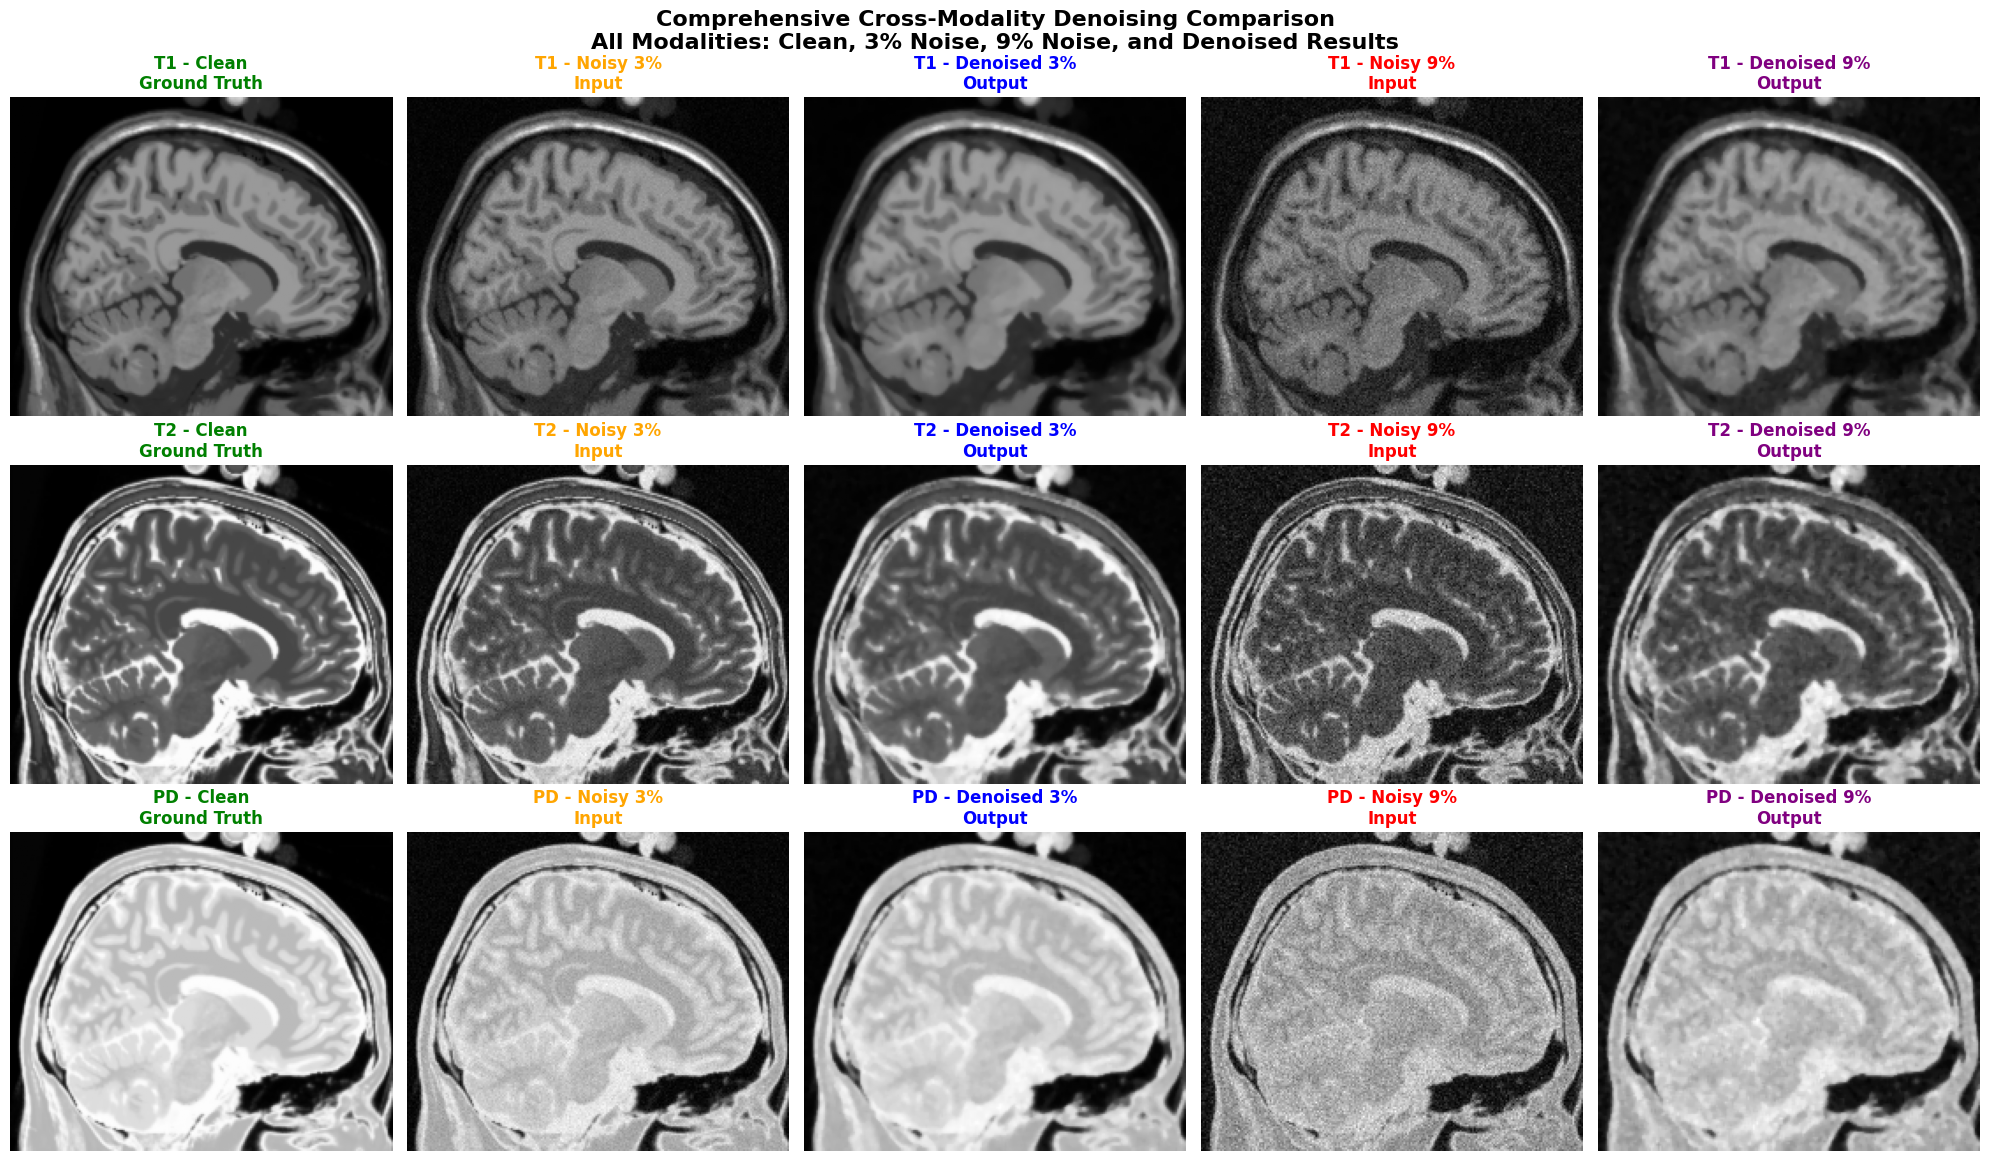


Generating quantitative summary visualization...


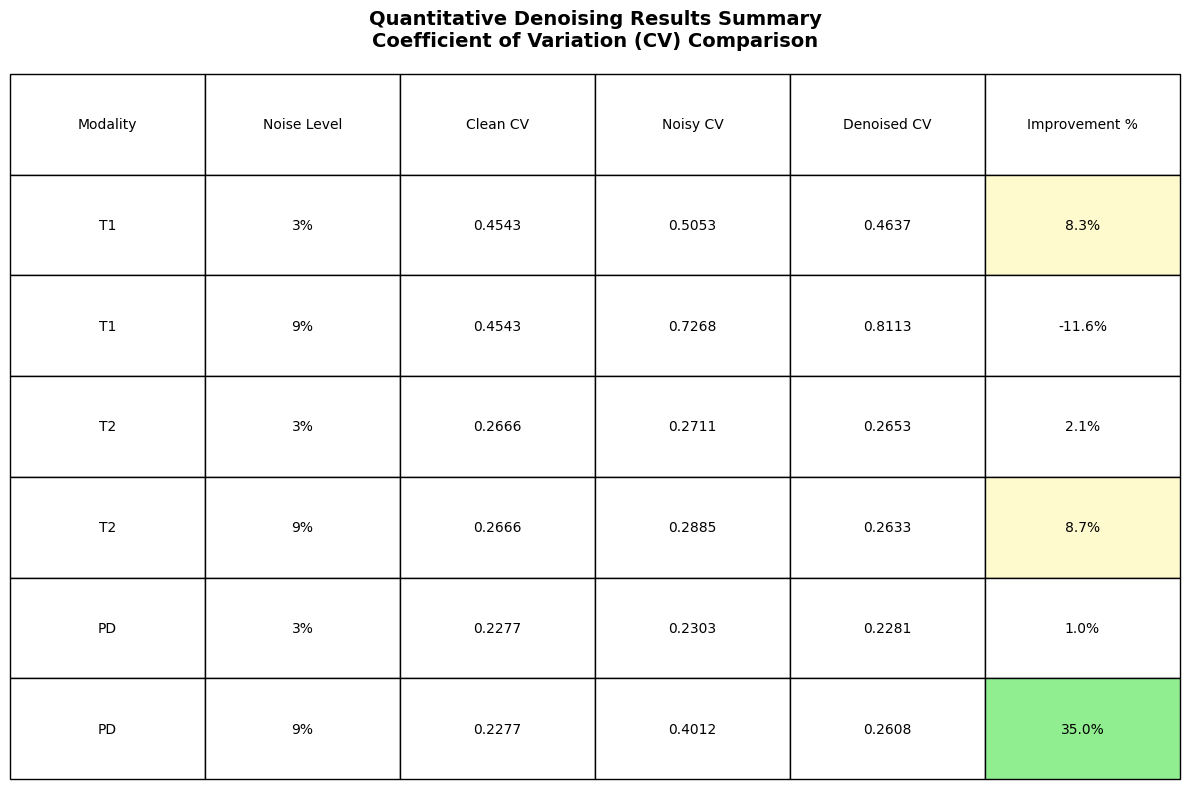


Generating noise removal visualization...


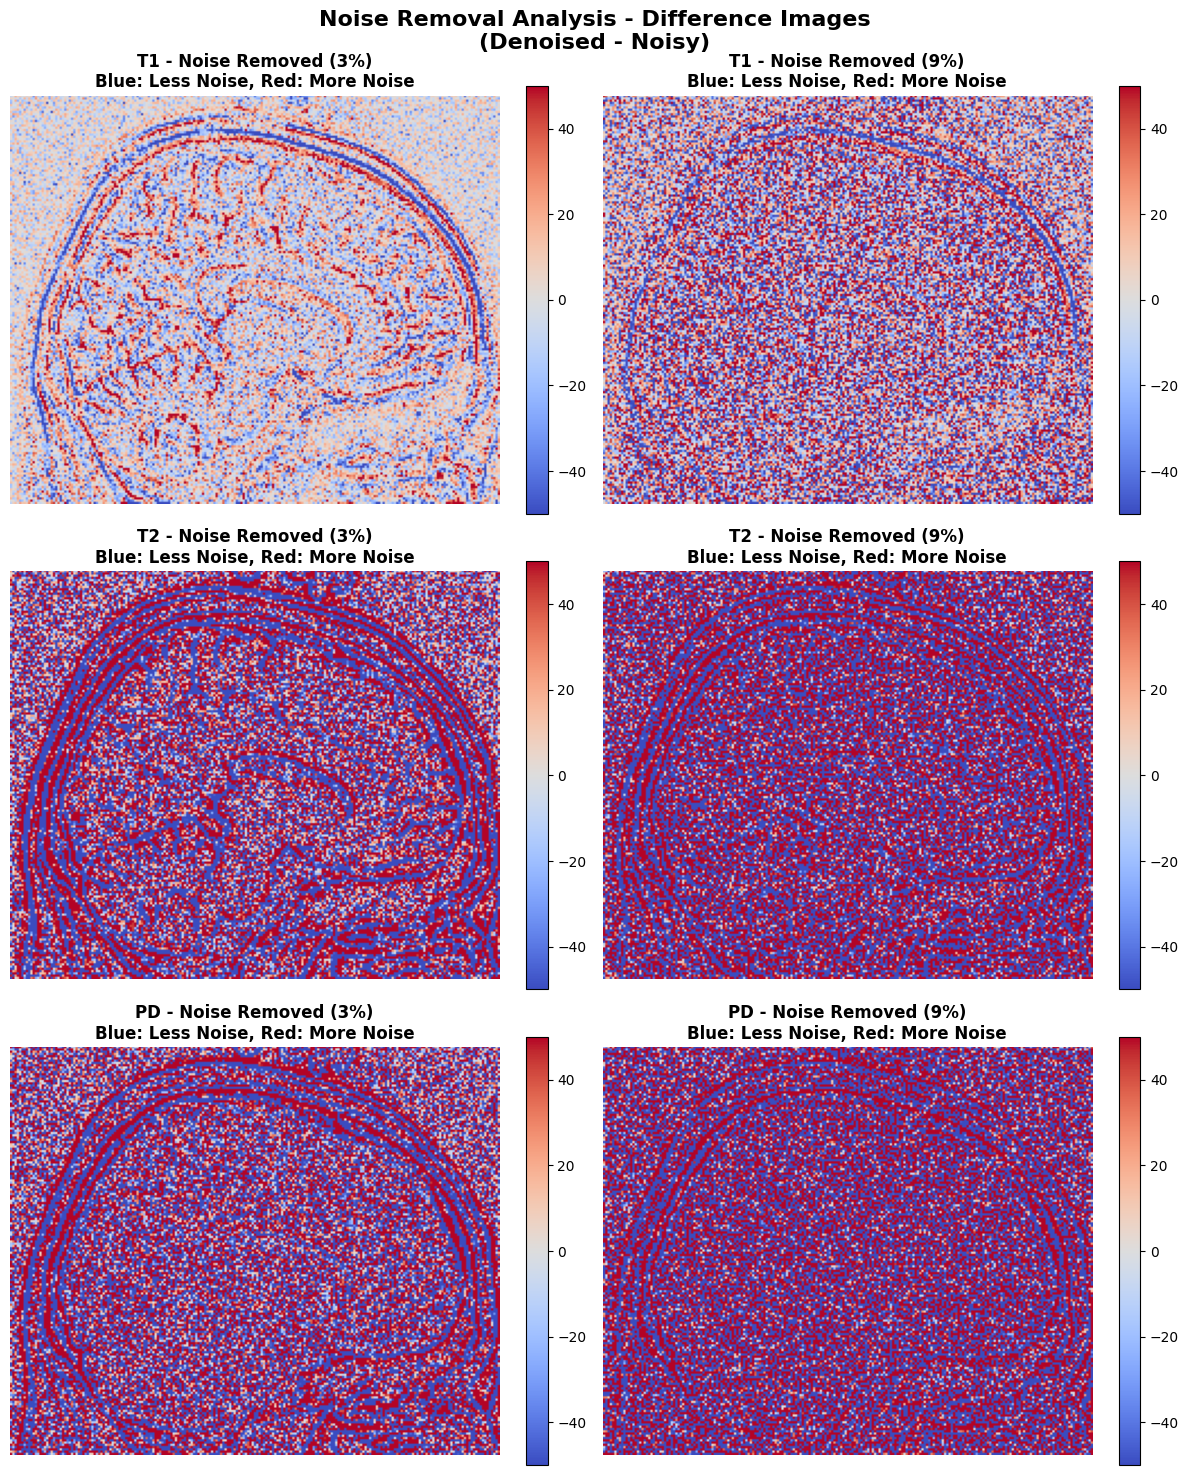

In [16]:
print("\nGenerating COMPREHENSIVE cross-modality comparison...")

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Comprehensive Cross-Modality Denoising Comparison\nAll Modalities: Clean, 3% Noise, 9% Noise, and Denoised Results',
             fontsize=16, fontweight='bold')

modalities = ['T1', 'T2', 'PD']
slice_idx = 100

for i, modality in enumerate(modalities):
    # Column 1: Clean (Ground Truth)
    axes[i,0].imshow(clean_images[modality][:,:,slice_idx], cmap='gray', origin='lower')
    axes[i,0].set_title(f'{modality} - Clean\nGround Truth', fontweight='bold', color='green')
    axes[i,0].axis('off')

    # Column 2: 3% Noisy
    key_3 = f"{modality}_3"
    axes[i,1].imshow(noisy_images[key_3][:,:,slice_idx], cmap='gray', origin='lower')
    axes[i,1].set_title(f'{modality} - Noisy 3%\nInput', fontweight='bold', color='orange')
    axes[i,1].axis('off')

    # Column 3: Denoised 3%
    axes[i,2].imshow(denoised_results[key_3][:,:,slice_idx], cmap='gray', origin='lower')
    axes[i,2].set_title(f'{modality} - Denoised 3%\nOutput', fontweight='bold', color='blue')
    axes[i,2].axis('off')

    # Column 4: 9% Noisy
    key_9 = f"{modality}_9"
    axes[i,3].imshow(noisy_images[key_9][:,:,slice_idx], cmap='gray', origin='lower')
    axes[i,3].set_title(f'{modality} - Noisy 9%\nInput', fontweight='bold', color='red')
    axes[i,3].axis('off')

    # Column 5: Denoised 9%
    axes[i,4].imshow(denoised_results[key_9][:,:,slice_idx], cmap='gray', origin='lower')
    axes[i,4].set_title(f'{modality} - Denoised 9%\nOutput', fontweight='bold', color='purple')
    axes[i,4].axis('off')

plt.tight_layout()
plt.savefig(base_path + 'comprehensive_cross_modality_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional: Quantitative Comparison Table Visualization
print("\nGenerating quantitative summary visualization...")

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.axis('tight')
ax.axis('off')

# Prepare data for table
table_data = []
headers = ['Modality', 'Noise Level', 'Clean CV', 'Noisy CV', 'Denoised CV', 'Improvement %']

for modality in ['T1', 'T2', 'PD']:
    cv_clean = calculate_final_cv(clean_images[modality], modality)

    for noise_level in ['3%', '9%']:
        key = f"{modality}_{noise_level[0]}"  # Remove % symbol
        cv_noisy = calculate_final_cv(noisy_images[key], modality)
        cv_denoised = calculate_final_cv(denoised_results[key], modality)
        improvement = ((cv_noisy - cv_denoised) / cv_noisy * 100)

        table_data.append([
            modality,
            noise_level,
            f"{cv_clean:.4f}",
            f"{cv_noisy:.4f}",
            f"{cv_denoised:.4f}",
            f"{improvement:.1f}%"
        ])

# Create table
table = ax.table(cellText=table_data,
                colLabels=headers,
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Color code improvements
for i in range(1, len(table_data) + 1):
    improvement = float(table_data[i-1][5].rstrip('%'))
    if improvement > 10:
        table[(i, 5)].set_facecolor('#90EE90')  # Light green for good improvement
    elif improvement > 5:
        table[(i, 5)].set_facecolor('#FFFACD')  # Light yellow for moderate improvement

ax.set_title('Quantitative Denoising Results Summary\nCoefficient of Variation (CV) Comparison',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(base_path + 'quantitative_results_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Final: Noise Removal Visualization
print("\nGenerating noise removal visualization...")

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
fig.suptitle('Noise Removal Analysis - Difference Images\n(Denoised - Noisy)', fontsize=16, fontweight='bold')

for i, modality in enumerate(modalities):
    # 3% Noise Removal
    key_3 = f"{modality}_3"
    diff_3 = denoised_results[key_3][:,:,slice_idx] - noisy_images[key_3][:,:,slice_idx]
    im1 = axes[i,0].imshow(diff_3, cmap='coolwarm', vmin=-50, vmax=50, origin='lower')
    axes[i,0].set_title(f'{modality} - Noise Removed (3%)\nBlue: Less Noise, Red: More Noise', fontweight='bold')
    axes[i,0].axis('off')
    plt.colorbar(im1, ax=axes[i,0], fraction=0.046)

    # 9% Noise Removal
    key_9 = f"{modality}_9"
    diff_9 = denoised_results[key_9][:,:,slice_idx] - noisy_images[key_9][:,:,slice_idx]
    im2 = axes[i,1].imshow(diff_9, cmap='coolwarm', vmin=-50, vmax=50, origin='lower')
    axes[i,1].set_title(f'{modality} - Noise Removed (9%)\nBlue: Less Noise, Red: More Noise', fontweight='bold')
    axes[i,1].axis('off')
    plt.colorbar(im2, ax=axes[i,1], fraction=0.046)

plt.tight_layout()
plt.savefig(base_path + 'noise_removal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()